# eTraGo: electric Transmission Grid optimization

The following notebook shows you how you can apply the basic functions of eTraGo.
It is structured into two different sections: 

1) Minimal example demonstrating eTraGo's usage
2) Analyzing and disaggregating results of a representative calculation


More information on the installation of eTraGo, the described functions, as well as a description of all options, is provided in the __[eTraGo Documentation on read the docs](http://etrago.readthedocs.io/)__

## Import required general and eTraGo specific python packages

In [5]:
import warnings
warnings.filterwarnings('ignore')

from etrago import Etrago
from etrago.analyze.plot import coloring
import pypsa


In [6]:
%matplotlib inline

# 1 Minimal example demonstrating eTraGo's usage

This section demonstrates the general usage of eTraGo using a minimal example.
The minimal example only considers a few snapshots, and the electrical grid is clustered to a few nodes. Thus, the results can not be used for a real analysis which requires more time steps, nodes, and therefore increased calculation time and computational resources.

The following subsections will explain and demonstrate the different functionalities given in the schema:

![Image eTraGo's functionalities](https://raw.githubusercontent.com/openego/eTraGo/0.10.1/doc/images/etrago_functionalities.png)


## 1.1 Initialize object and set parameters

All parameters of an eTraGo calculation are stored in etrago.args.
They can be defined via a json-file or as a dictionary. Documentation on all parameters is provided in the read the docs. 

In [3]:
etrago = Etrago(args={}, json_path="args_minimal_example.json")

### Energy system scenario
The input data includes the starting grid topology as well as all energy demands, generation and sorage options. It is created with the open source tool *eGon-data*. The resulting data models are stored on the *OpenEnergyPlatform*, eTraGo directly accesses the data from there. 
In this example, the mid term scenario *eGon2035* is used, which mainly bases on the *Netzentwicklungsplan Strom 2035, Version 2021, Szenaro C 2035*.

In [4]:
# Scenario name
etrago.args["scn_name"]

'eGon2035'

### Snapshots considered in calculation
For a small example, a limited number of snapshots is selected. For larger, annual calculations eTraGo needs more RAM then a normal laptop provides, so calculations are done on a server.
The snapshots are defined as the nth number in a year, so it can be between 1 and 8760.
In this example, the first day of the year is selected:

In [5]:
print(etrago.args["start_snapshot"])
print(etrago.args["end_snapshot"])

1
24


## 1.3 Data model and scenario variation

In [6]:
etrago.build_network_from_db()
etrago.adjust_network()

INFO:etrago.tools.io:Importing Buses from database
INFO:etrago.tools.io:Importing Lines from database
INFO:etrago.tools.io:Importing Transformers from database
INFO:etrago.tools.io:Importing Links from database
INFO:etrago.tools.io:Importing Loads from database
INFO:etrago.tools.io:Importing Generators from database
INFO:etrago.tools.io:Importing Storages from database
INFO:etrago.tools.io:Importing Stores from database
INFO:etrago.network:Imported network from db
INFO:etrago.tools.utilities:
            There are 7 lines without a resistance (r) in the data model.
            The resistance of these lines will be automatically set to 0.0001.
            
INFO:etrago.tools.utilities:There are 518 trafos without a resistance (r) in the data model.
            The resistance of these trafos will be automatically set to 0.0001.
            


## 1.4 Complexity Reduction
The data model is characterized by a high spatial (about 8,000 electrical and 600 gas nodes) and temporal resolution (8,760 timesteps). To reduce the complexity of the resulting optimization problem, several methods can be applied.
In this example, we focus on the spatial complexity reduction.

This is how the network looks like in the original resolution:

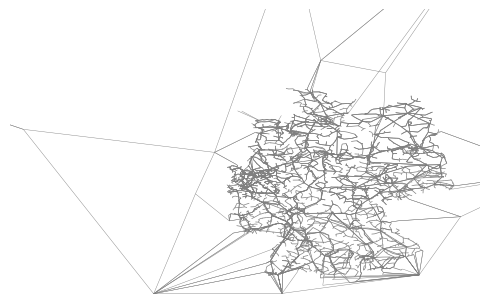

In [7]:
etrago.plot_grid("grey")

In the following, spatial complexity methods are applied. In this minimal example, the electrical network is clustered to 30 nodes.

_Please note that this step can take a few minutes._

In [8]:
# run spatial clustering
etrago.spatial_clustering()
etrago.spatial_clustering_gas()
etrago.network.export_to_csv_folder("clustered_grid")

INFO:etrago.cluster.electrical:

                ----------------------- WARNING ---------------------------
                THE FOLLOWING BUSES HAVE NOT COUNTRY DATA:
                ['13665', '13478', '12770', '13824'].
                THEY WILL BE ASSIGNED TO GERMANY, BUT IT IS POTENTIALLY A
                SIGN OF A PROBLEM IN THE DATASET.
                ----------------------- WARNING ---------------------------

                
INFO:etrago.cluster.electrical:Start k-medoids Dijkstra Clustering AC
INFO:etrago.cluster.electrical:Network clustered to 30 buses with kmedoids-dijkstra
INFO:etrago.cluster.gas:Start kmedoids-dijkstra clustering GAS
       '48879', '48880',
       ...
       '49480', '49481', '49482', '49483', '49484', '49485', '49486', '49487',
       '49488', '49489'],
      dtype='object', name='Bus', length=619)
       '48717', '48718', '48765', '48863'],
      dtype='object', name='Bus')
INFO:etrago.cluster.gas:CH4 Network clustered to 2 DE-buses and 13 foreign bus

Afterwards, the electrical grid looks like this:

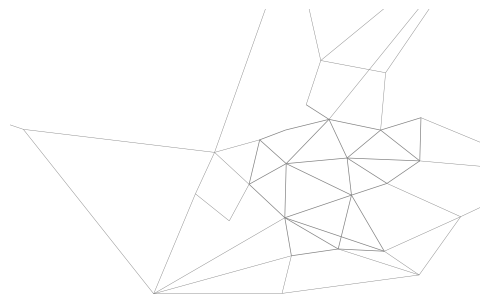

In [9]:
etrago.plot_grid("grey")

## 1.5 Optimization

eTraGo includes different methods to optimize the German energy system, including the eHV/HV grid.
In this example, an integrated LOPF is selected. This optimizes the dispatch of generation and flexibility options as well as grid and storage expansion in one integrated optimization step.

_Please note that the solver glpk needs to be installed for this minimal example._

In [10]:
etrago.optimize()

INFO:linopy.model: Solve problem using Glpk solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 386.36it/s]
INFO:linopy.io: Writing time: 0.41s


GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --lp /tmp/linopy-problem-y_2e9g1l.lp --output /tmp/linopy-solve-vn0_4mep.sol
Reading problem data from '/tmp/linopy-problem-y_2e9g1l.lp'...
56830 rows, 26815 columns, 107654 non-zeros
314407 lines were read
GLPK Simplex Optimizer 5.0
56830 rows, 26815 columns, 107654 non-zeros
Preprocessing...
17472 rows, 23919 columns, 65117 non-zeros
Scaling...
 A: min|aij| =  4.200e-01  max|aij| =  3.832e+02  ratio =  9.125e+02
GM: min|aij| =  3.192e-01  max|aij| =  3.133e+00  ratio =  9.815e+00
EQ: min|aij| =  1.036e-01  max|aij| =  1.000e+00  ratio =  9.649e+00
Constructing initial basis...
Size of triangular part is 17452
      0: obj =   6.336958242e+08 inf =   2.444e+07 (1721)
   8335: obj =   9.676441913e+08 inf =   1.155e-13 (0) 33
* 16899: obj =   5.236763828e+08 inf =   2.424e-12 (5825) 55
* 25619: obj =   4.834252611e+08 inf =   2.856e-12 (2449) 56
* 29221: obj =   4.831796772e+08 inf =   1.875e-11 (0) 28
OPTIMAL L

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 26815 primals, 56830 duals
Objective: 4.83e+08
Solver model: not available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-ext-s-lower, Line-ext-s-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance, Store-energy_balance were not as

Time for LOPF [min]: 0.3


## 1.6 Result analysis

eTraGo includes different functions to analyze the results.

_Please note that the results of the minimal example are not representative, they are just shown to explain the general usage._

In the following, a map of grid and storage expansion is visualized:

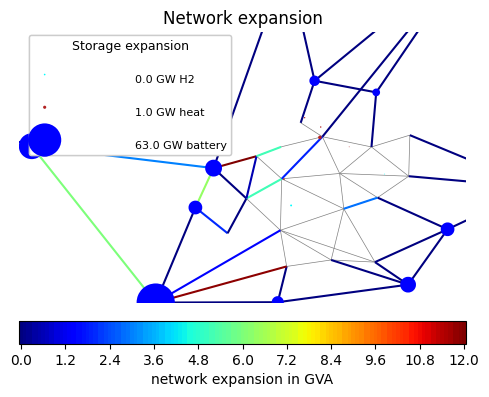

In [11]:
etrago.plot_grid(
    line_colors="expansion_abs",
    bus_colors = "storage_expansion", bus_sizes= 0.000001,
    scaling_store_expansion={"H2": 10,
                            "heat": 10,
                            "battery": 10})

# 2 Analyzing and disaggregating results of a representative calculation

eTraGo also includes several functions to analyze the results. These are demonstrated using results of bigger calculations which are published on Zenodo. 
That data is also used to show the results of spatial and temporal disaggregation that is the basis for the interface to underlying distribution grids.

The results of the optimization are available here: https://zenodo.org/records/10160482 

The disaggregated results are available here: https://zenodo.org/records/15880516

Please adjust the paths to your downloaded files accordingly. 

In [12]:
# Insert the path to the prepared data here
path = "/.../base"
path_disaggregated = "/.../base_network.nc"

## 2.1 Loading predefined results

In [7]:
etrago_larger_model = Etrago(results_folder_name=path)

                    No args.json in /home/dozeumesk/eTraGo/git/eTraGo/etrago-big-results/eTraGo-Paper//base available.
                    
INFO:pypsa.io:Imported network base has buses, generators, lines, links, loads, storage_units, stores
INFO:etrago.network:
                        No disaggregated network available.
                        
INFO:etrago.network:
                            No separate market model available.
                            


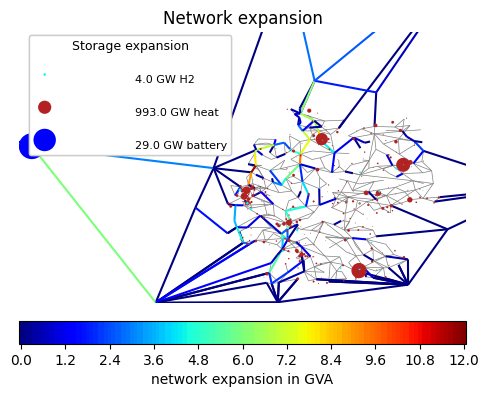

In [11]:
etrago_larger_model.plot_grid(
    line_colors="expansion_abs",
    bus_colors = "storage_expansion", bus_sizes= 0.000001,
    scaling_store_expansion={"H2": 1,
                            "heat": 0.1,
                            "battery": 10})

eTraGo also includes functions to calculate general results as tables, such as system costs and total grid expansion:

In [27]:
etrago_larger_model.calc_results()
etrago_larger_model.results.loc["annual electrical grid investment costs"]

unit                 EUR/a
value    1155635219.914265
Name: annual electrical grid investment costs, dtype: object

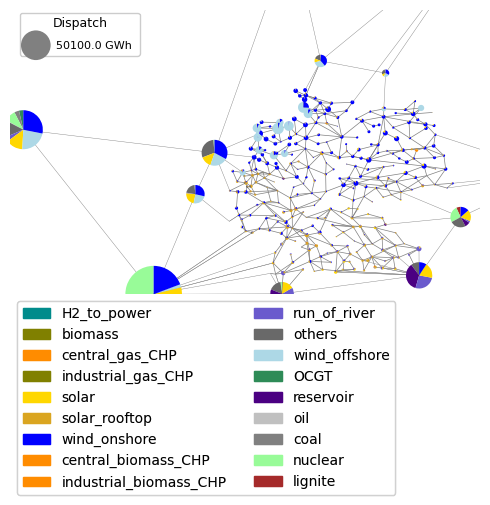

In [28]:
etrago_larger_model.plot_grid(
    line_colors="grey",
    bus_colors = "gen_dist",
    bus_sizes= 1e-8,
    timesteps = range(1752))

## 2.2 Desaggregation results to the original resolution - Interface to distribution grids

The results can be disaggregated to the original resolution in both temporal and spatial dimension. This is esp. required for the interface to the underlying distribution grids.

After the disaggregation the grid provides data for each HV/MV substation for every hour of the year:

In [29]:
etrago_larger_model.disaggregated_network = pypsa.Network(path_disaggregated)

INFO:pypsa.io:Imported network base_network.nc has buses, generators, lines, links, loads, storage_units, stores, transformers


In [ ]:
etrago_larger_model.plot_grid(
    line_colors="grey",
    apply_on = "disaggreagted_network",
    bus_colors = "gen_dist",
    bus_sizes= 1e-8,
    timesteps = range(1752))

In [ ]:
mv_id = "33128"

gens = etrago_larger_model.disaggregated_network.generators[etrago_larger_model.disaggregated_network.generators.bus==mv_id]

df = etrago_larger_model.disaggregated_network.generators_t.p[gens.index].groupby(gens.carrier, axis=1).sum()

df.plot(kind="area", stacked = True, color=coloring())

These dispatch time series per HV/MV substation are handed over to the underlying MV/LV grids. They are considered there as conatraints to make sure that the overall results in consistent across all voltage levels.